In [1]:
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np

from mdx2.io import loadobj
from mdx2.report.map_statistics import calc_correlation_of_half_datasets, calc_intensity_statistics, prepare_table

# Map statistics

Compute statistics for merged diffuse map

## Parameters

In [2]:
# These metadata fields are injected by mdx2.report, regardless of the template. Don't change this line.
_metadata: dict = {}

# Notebook parameters
#input_files: list[str] = None # list of input file paths: required
crystal_source: str = None  # (nexus_file_path:object name)
symmetry_source: str = None  # (nexus_file_path:object name)
hkl_table_source: str = None  # (nexus_file_path:object name)

bin_width: float = 0.01  # bin width for statistics vs s

In [3]:
# Parameters
crystal_source = "../split_00/geometry.nxs:crystal"
symmetry_source = "../split_00/geometry.nxs:symmetry"
hkl_table_source = "../merged_all.nxs:hkl_table"
bin_width = 0.01
_metadata = {"author": "Steve Meisburger", "date_created": "2026-04-17 13:39:54", "mdx2_version": "1.0.3", "environment": "cbsuando2.biohpc.cornell.edu", "working_directory": "/local/storage/steve/mdx2_dev/examples/insulin-multi-crystal/mdx2/reports", "notebook_template": "map_statistics"}


In [4]:
# pretty-print the metadata and parameters
pprint({
    "metadata": _metadata,
    "parameters": {"crystal_source": crystal_source,
                   "symmetry_source": symmetry_source,
                   "hkl_table_source": hkl_table_source,
                   "bin_width": bin_width,
                   },
})

{'metadata': {'author': 'Steve Meisburger',
              'date_created': '2026-04-17 13:39:54',
              'environment': 'cbsuando2.biohpc.cornell.edu',
              'mdx2_version': '1.0.3',
              'notebook_template': 'map_statistics',
              'working_directory': '/local/storage/steve/mdx2_dev/examples/insulin-multi-crystal/mdx2/reports'},
 'parameters': {'bin_width': 0.01,
                'crystal_source': '../split_00/geometry.nxs:crystal',
                'hkl_table_source': '../merged_all.nxs:hkl_table',
                'symmetry_source': '../split_00/geometry.nxs:symmetry'}}


## Results

In [5]:
crystal = loadobj(*crystal_source.split(":"))
symmetry = loadobj(*symmetry_source.split(":"))
hkl_table = loadobj(*hkl_table_source.split(":"))

### Map properties

In [6]:
def _calc_unit_cell(ub):
    a, b, c = ub[:, 0], ub[:, 1], ub[:, 2]
    a_len = np.linalg.norm(a)
    b_len = np.linalg.norm(b)
    c_len = np.linalg.norm(c)
    alpha = np.arccos(np.dot(b, c) / (b_len * c_len)) * 180 / np.pi
    beta = np.arccos(np.dot(a, c) / (a_len * c_len)) * 180 / np.pi
    gamma = np.arccos(np.dot(a, b) / (a_len * b_len)) * 180 / np.pi
    return a_len, b_len, c_len, alpha, beta, gamma

print("Laue group:", symmetry.laue_group_symbol)
a, b, c, alpha, beta, gamma = _calc_unit_cell(crystal.ub_matrix)
print("Reciprocal cell dimensions")
print("   a*, b*, c* (Å⁻¹): {:.5f}, {:.5f}, {:.5f}".format(a, b, c))
print("     α*, β*, γ* (°): {:.2f}, {:.2f}, {:.2f}".format(alpha, beta, gamma))
print("Reciprocal cell volume (Å⁻³): {:.3e}".format(np.linalg.det(crystal.ub_matrix)))
print("Voxel subdivisions:", hkl_table.ndiv)
print("Voxel volume (Å⁻³): {:.3e}".format(np.linalg.det(crystal.ub_matrix) / np.prod(hkl_table.ndiv)))

Laue group: m-3
Reciprocal cell dimensions
   a*, b*, c* (Å⁻¹): 0.01257, 0.01257, 0.01257
     α*, β*, γ* (°): 90.00, 90.00, 90.00
Reciprocal cell volume (Å⁻³): 1.988e-06
Voxel subdivisions: (3, 3, 3)
Voxel volume (Å⁻³): 7.363e-08


In [7]:
df = prepare_table(hkl_table, crystal, symmetry, bin_width=bin_width)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
h,1491320.0,1.049300e+01,7.947499e+00,0.000000e+00,4.000000e+00,9.000000e+00,1.566667e+01,3.833333e+01
k,1491320.0,3.287805e+01,1.470745e+01,3.333333e-01,2.166667e+01,3.266667e+01,4.366667e+01,6.833333e+01
l,1491320.0,3.274926e+01,1.481570e+01,0.000000e+00,2.133333e+01,3.233333e+01,4.366667e+01,6.833333e+01
s,1491320.0,6.396717e-01,1.660704e-01,2.903786e-02,5.366605e-01,6.769361e-01,7.753819e-01,8.639880e-01
intensity,1491320.0,3.957047e+07,1.613458e+07,-2.251938e+07,3.064967e+07,3.229956e+07,3.951618e+07,3.307831e+08
intensity_error,1491320.0,6.443718e+05,2.718796e+06,3.738423e+04,2.386588e+05,2.715569e+05,5.252507e+05,2.543562e+08
multiplicity,1491320.0,7.623094e+01,4.496711e+01,1.000000e+00,3.000000e+01,9.900000e+01,1.120000e+02,5.560000e+02
group_0_intensity,1481789.0,3.964348e+07,1.618228e+07,-2.251938e+07,3.075292e+07,3.238391e+07,3.977664e+07,3.717647e+08
group_1_intensity,1481834.0,3.964604e+07,1.618616e+07,-1.706635e+07,3.075402e+07,3.238451e+07,3.976650e+07,3.307831e+08
intensity_iso,1491320.0,3.935338e+07,1.557142e+07,9.616318e+06,3.047076e+07,3.226161e+07,3.885877e+07,9.008180e+07


### Statistics vs. resolution

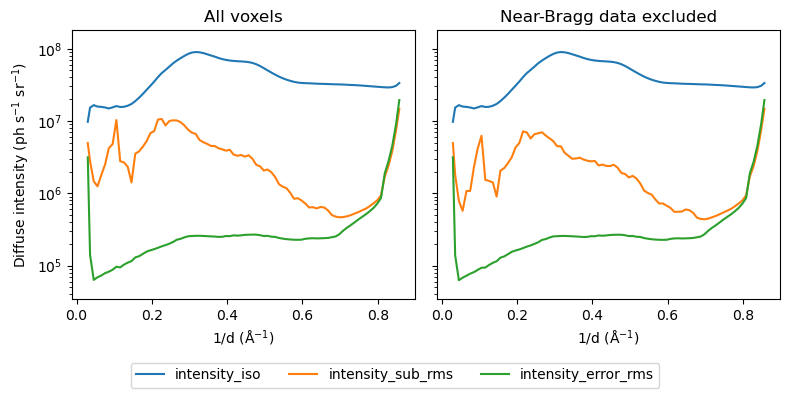

In [8]:
# compute the statistics with and without voxels centered on Bragg reflections (strong halos can dominate stats)
df_isoavg_all = calc_intensity_statistics(df, bin_width=bin_width, exclude_bragg=False)
df_isoavg_excluded = calc_intensity_statistics(df, bin_width=bin_width, exclude_bragg=True)

def _set_tight_limits(df, ax):
    df = df.drop(columns=['s'])
    col_mins = df.where(df > 0).min()
    col_maxs = df.max()
    vmin = col_mins.min()
    vmax = col_maxs.max()
    ax.set_ylim(vmin*0.5, vmax*2)

fig, (ax0, ax1) = plt.subplots(1, 2, sharey=True, figsize=(8, 4))

df_isoavg_all.set_index('s').plot(logy=True, ax=ax0, title="All voxels", legend=False)
ax0.set_ylabel("Diffuse intensity (ph s$^{-1}$ sr$^{-1}$)")

df_isoavg_excluded.set_index('s').plot(logy=True, ax=ax1, title="Near-Bragg data excluded", legend=False)
_set_tight_limits(df_isoavg_excluded.iloc[5:-5], ax1) # exclude the first and last 5 bins when setting limits.

[ax.set_xlabel("1/d (Å$^{-1}$)") for ax in (ax0, ax1)]
fig.legend(*ax1.get_legend_handles_labels(), loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Correlelation between half-datasets

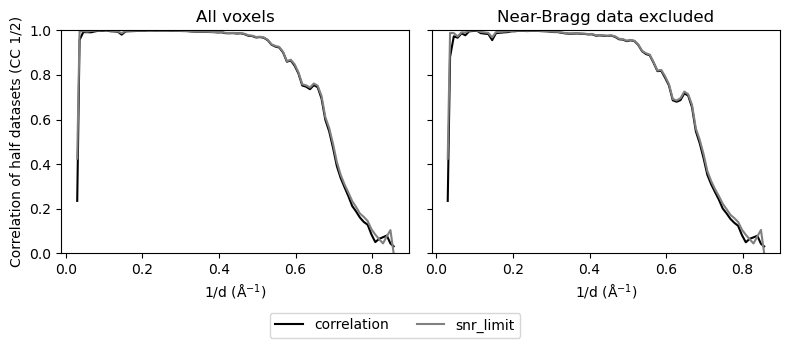

In [9]:
# compute the statistics with and without voxels centered on Bragg reflections (strong halos can dominate stats)
if "group_0_intensity" not in df.columns:
    print("The hkl_table does not contain split intensities, skipping correlation plot")
else:
    df_cc_all = calc_correlation_of_half_datasets(df, bin_width=bin_width, exclude_bragg=False)
    df_cc_excluded = calc_correlation_of_half_datasets(df, bin_width=bin_width, exclude_bragg=True)
    colors = ["black", "gray"]

    fig, (ax0, ax1) = plt.subplots(1, 2, sharey=True, figsize=(8, 3.5))
    df_cc_all.set_index('s').plot(ax=ax0, title="All voxels", legend=False, color=colors)
    ax0.set_ylabel("Correlation of half datasets (CC 1/2)")

    df_cc_excluded.set_index('s').plot(ax=ax1, title="Near-Bragg data excluded", legend=False, color=colors)
    ax1.set_ylim(0, 1)

    [ax.set_xlabel("1/d (Å$^{-1}$)") for ax in (ax0, ax1)]
    fig.legend(*ax1.get_legend_handles_labels(), loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()